In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
cbb_df = pd.read_csv('cbb.csv')
cbb_df.head()

,TEAM,CONF,G,W,ADJOE,ADJDE,BARTHAG,EFG_O,EFG_D,TOR,...,FTRD,2P_O,2P_D,3P_O,3P_D,ADJ_T,WAB,POSTSEASON,SEED,YEAR
0,North Carolina,ACC,40,33,123.3,94.9,0.9531,52.6,48.1,15.4,...,30.4,53.9,44.6,32.7,36.2,71.7,8.6,2ND,1.0,2016
1,Wisconsin,B10,40,36,129.1,93.6,0.9758,54.8,47.7,12.4,...,22.4,54.8,44.7,36.5,37.5,59.3,11.3,2ND,1.0,2015
2,Michigan,B10,40,33,114.4,90.4,0.9375,53.9,47.7,14.0,...,30.0,54.7,46.8,35.2,33.2,65.9,6.9,2ND,3.0,2018
3,Texas Tech,B12,38,31,115.2,85.2,0.9696,53.5,43.0,17.7,...,36.6,52.8,41.9,36.5,29.7,67.5,7.0,2ND,3.0,2019
4,Gonzaga,WCC,39,37,117.8,86.3,0.9728,56.6,41.1,16.2,...,26.9,56.3,40.0,38.2,29.0,71.5,7.7,2ND,1.0,2017


### Dataset Features
This dataset contains one row per team-season in Division I men's college basketball.

- `TEAM`: Team name.
- `CONF`: Conference abbreviation (for example, ACC = Atlantic Coast Conference, B10 = Big Ten Conference, SEC = Southeastern Conference).
- `YEAR`: Season year.
- `G`, `W`: Games played and games won.
- `POSTSEASON`, `SEED`: NCAA tournament round result and tournament seed.

Efficiency and rating metrics:
- `ADJOE`: Adjusted offensive efficiency (points scored per 100 possessions, adjusted for opponent/tempo). Higher is better.
- `ADJDE`: Adjusted defensive efficiency (points allowed per 100 possessions, adjusted). Lower is better.
- `BARTHAG`: Overall power rating derived from offensive and defensive efficiency. Higher indicates a stronger team.
- `WAB`: Wins Above Bubble, an estimate of how much better a resume is than a typical NCAA bubble team. Higher is better.

Style and shot profile metrics (percentages):
- `EFG_O`, `EFG_D`: Effective field goal percentage on offense and allowed on defense (accounts for extra value of 3-pointers).
- `2P_O`, `2P_D`: 2-point shooting percentage on offense and allowed on defense.
- `3P_O`, `3P_D`: 3-point shooting percentage on offense and allowed on defense.
- `FTR`, `FTRD`: Free throw rate on offense and allowed on defense (free throw attempts relative to field goal attempts).
- `TOR`, `TORD`: Turnover rate on offense and turnovers forced on defense.
- `ORB`, `DRB`: Offensive and defensive rebounding rates.
- `ADJ_T`: Adjusted tempo (possessions per 40 minutes). Higher values indicate faster pace.

### Conference Strength Distribution (Box Plot)
This box plot compares `BARTHAG` across major conferences: Atlantic Coast Conference (ACC), Big Ten Conference (B10), Big 12 Conference (B12), Southeastern Conference (SEC), Big East Conference (BE), Pac-12 Conference (P12), and Atlantic 10 Conference (A10). This plot shows the  "strength of schedule" and conference prestige. It shows whether a conference is top-heavy (one great team, many bad ones) or deep (many competitive teams). The conferences are ordered by median `BARTHAG`, so differences in conference depth and top-end quality are easier to compare. 


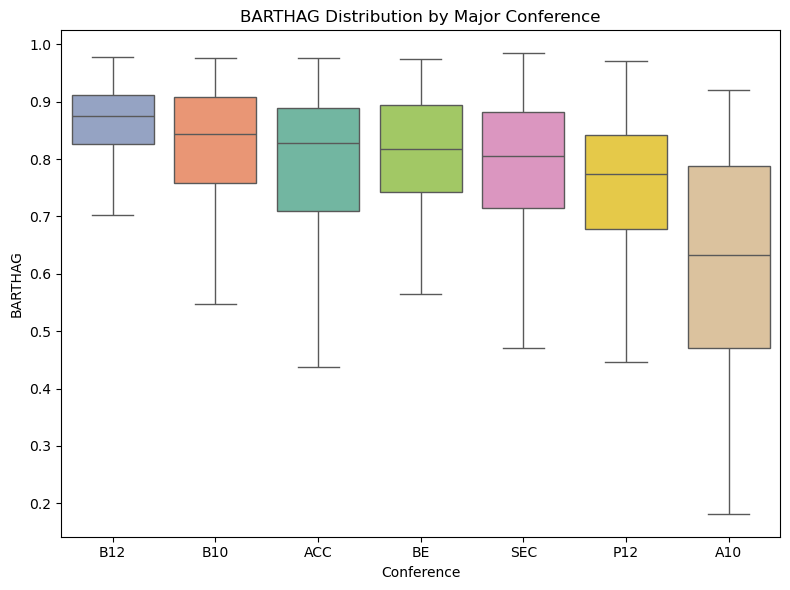

In [3]:
major_confs = ['ACC', 'B10', 'B12', 'SEC', 'BE', 'P12', 'A10']
conf_df = cbb_df[cbb_df['CONF'].isin(major_confs)].copy()

conf_order = (
    conf_df.groupby('CONF')['BARTHAG']
    .median()
    .sort_values(ascending=False)
    .index
)

plt.figure(figsize=(8, 6))
sns.boxplot(
    data=conf_df,
    x='CONF',
    y='BARTHAG',
    hue='CONF',
    order=conf_order,
    palette='Set2',
    legend=False,
    showfliers=False
)
plt.title('BARTHAG Distribution by Major Conference')
plt.xlabel('Conference')
plt.ylabel('BARTHAG')
plt.tight_layout()
plt.show()



### Champion Profile Comparison (Radar Chart)
This radar chart compares the five most recent NCAA champions using `EFG_O`, `TOR`, `ORB`, `FTR`, and `ADJDE`.
To keep the chart readable, each metric is scaled to a simple 0-1 range using min-max normalization; `TOR` and `ADJDE` are inverted so higher values consistently indicate stronger performance on the plot.


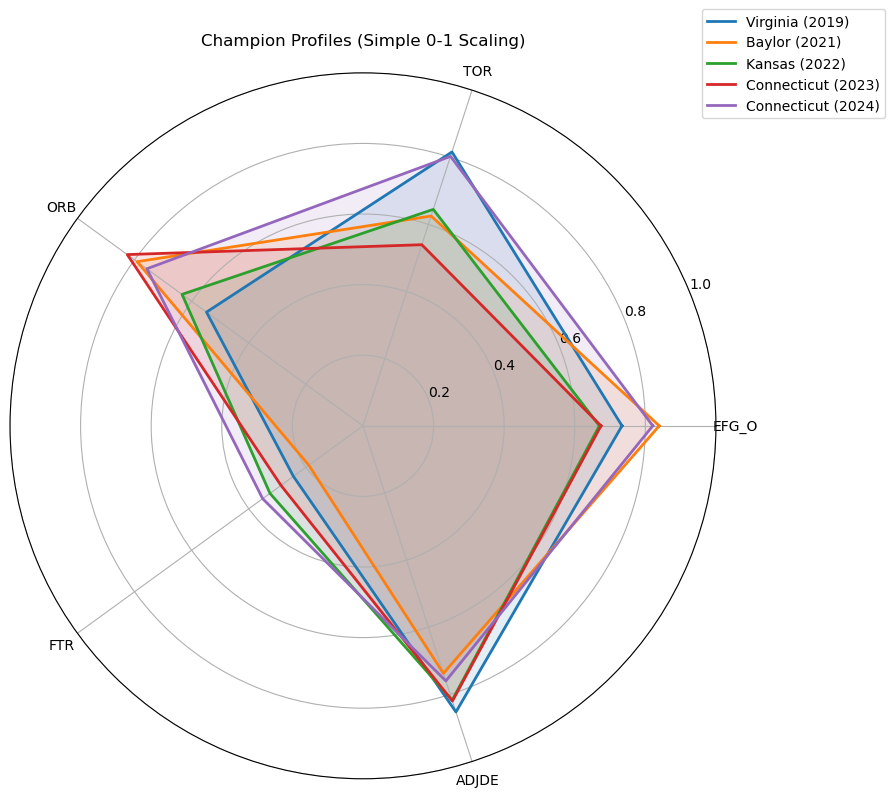

In [4]:
metrics = ['EFG_O', 'TOR', 'ORB', 'FTR', 'ADJDE']
lower_is_better = ['TOR', 'ADJDE']

champions = (
    cbb_df[cbb_df['POSTSEASON'] == 'Champions']
    .sort_values('YEAR')
    .tail(5)
    .copy()
)

scaled_profiles = champions[['TEAM', 'YEAR']].copy()
for metric in metrics:
    min_val = cbb_df[metric].min()
    max_val = cbb_df[metric].max()
    scaled = (champions[metric] - min_val) / (max_val - min_val)
    if metric in lower_is_better:
        scaled = 1 - scaled
    scaled_profiles[metric] = scaled

angles = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False).tolist()  # Create evenly spaced axis angles around the circle, one per metric.
angles += angles[:1]  # Repeat the first angle at the end so each polygon closes back to its starting point.

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw={'polar': True})
for _, row in scaled_profiles.iterrows():
    values = row[metrics].tolist()
    values += values[:1]
    label = f"{row['TEAM']} ({int(row['YEAR'])})"
    ax.plot(angles, values, linewidth=2, label=label)
    ax.fill(angles, values, alpha=0.12)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'])
ax.set_ylim(0, 1)
ax.set_title('Champion Profiles (Simple 0-1 Scaling)', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.25, 1.1))
plt.tight_layout()
plt.show()



### Findings: Champion Radar Chart
The radar chart shows that recent champions are not identical, but most push outward on shooting (`EFG_O`) and defense (`ADJDE`, inverted on the chart).
**Virginia (2019)** is the clearest defense/ball-security profile (strong `ADJDE` and low `TOR`), while **Baylor (2021)** and **Connecticut (2023)** stand out most on offensive rebounding (`ORB`).
**Connecticut (2024)** is the most balanced outer shape, with high values on `EFG_O`, `TOR` (inverted), `ORB`, and the best `FTR` of this five-team group.
The main tradeoff visible in the plot is that teams with very strong rebounding shapes do not always have equally strong turnover shapes, which supports the idea that there are multiple championship profiles rather than one single template.
